# Ayudantia 11

In [20]:
import pandas as pd
import numpy as np

Para abrirlo en colab: <a target="_blank" href="https://githubtocolab.com/SysBioengLab/IIQ3402-Statistical-Design/blob/main/Ayudantias/Ayudantia11_SuperficieDeRespuesta.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



# Diseno Experimental basado en Superficie de Respuesta: Disenos Central Composite Design

In [21]:
df_respuesta = pd.DataFrame({
    "xi1": [80.00, 80.00, 90.00, 90.00, 85.00, 85.00, 85.00, 85.00, 85.00, 92.07, 77.93, 85.00, 85.00],
    "xi2": [170.00, 180.00, 170.00, 180.00, 175.00, 175.00, 175.00, 175.00, 175.00, 175.00, 175.00, 182.07, 167.93],
    "x1":  [-1.000, -1.000,  1.000,  1.000,  0.000,  0.000,  0.000,  0.000,  0.000,  1.414, -1.414,  0.000,  0.000],
    "x2":  [-1.000,  1.000, -1.000,  1.000,  0.000,  0.000,  0.000,  0.000,  0.000,  0.000,  0.000,  1.414, -1.414],
    "y":   [76.5, 77.0, 78.0, 79.5, 79.9, 80.3, 80.0, 79.7, 79.8, 78.4, 75.6, 78.5, 77.0]
})
display(df_respuesta)

,xi1,xi2,x1,x2,y
0,80.00,170.00,-1.000,-1.000,76.5
1,80.00,180.00,-1.000,1.000,77.0
2,90.00,170.00,1.000,-1.000,78.0
3,90.00,180.00,1.000,1.000,79.5
4,85.00,175.00,0.000,0.000,79.9
5,85.00,175.00,0.000,0.000,80.3
6,85.00,175.00,0.000,0.000,80.0
7,85.00,175.00,0.000,0.000,79.7
8,85.00,175.00,0.000,0.000,79.8
9,92.07,175.00,1.414,0.000,78.4


> Explique la utilidad de los puntos axiales y el rol de $\alpha = \sqrt[4]{2^k}$. ?Que permiten modelar estos puntos en una superficie de segundo orden?

En un diseno de superficie de respuesta CCD (Central Composite Design) permite encontrar relevancia de efectos de segundo orden. Para esto se utilizan una serie de puntos axiales, descritos por $\alpha = \sqrt[4]{2^k}$, los que permiten hacer rotable el sistema, es decir, la varianza es la misma en todas las direcciones. Esta es una propiedad deseable del sistema dado a que permite realizar estimaciones de forma precisa en todas las direcciones del diseno.


## Ajuste modelo Cuadratico

> Estime un modelo cuadratico incluyendo terminos de primer orden, segundo orden e interacciones. Realice un ANOVA e interprete los efectos.

In [22]:
# Funciones auxliares para generar las formulas de los modelos
from itertools import combinations
from statsmodels.formula.api import ols
from scipy import stats
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt
def FirstOformula(*X):
    '''
    Pure First Order
    '''
    X = '+'.join(X)
    return X


def SecondOformula(*X):
    '''
    Pure Second Order
    '''
    X = '+'.join([f'np.power({x}, 2)' for x in X])
    return X

def TWIformula(*X):
    '''
    Two-way Interaction
    '''
    X_aux = []
    for i, j in combinations(range(len(X)), 2):
        X_aux.append(X[i] + ':' + X[j])
    X = '+'.join(X_aux)
    return X

formula_model = 'Yield ~ ' + FirstOformula('A', 'B', 'C', 'D', 'E') + '+' + \
    TWIformula('A', 'B', 'C', 'D', 'E')

def FirstO(*X):
    '''
    Pure First Order
    '''
    X = [x.values for x in X]
    return np.concatenate([X], axis = 1).T

def SecondO(*X):
    '''
    Pure Second Order
    '''
    X_aux = [x.values**2 for x in X]
    X_aux = np.concatenate([X_aux], axis = 1).T
    # get unique item
    X_unique = np.unique(X_aux, axis = 1)
    return X_unique


def TWI(*X):
    '''
    Two-way Interaction
    '''
    X = [x.values for x in X]
    interaction_terms = []

    # Calculo de terminos de interaccion
    for i, j in combinations(range(len(X)), 2):
        interaction_terms.append(X[i] * X[j])
    return np.concatenate([interaction_terms], axis = 1).T

formula = 'y ~ '+ FirstOformula('x1', 'x2') + '+' + \
    SecondOformula('x1', 'x2') + '+' + TWIformula('x1', 'x2')
ols_res = ols(formula, data=df_respuesta).fit()
print(ols_res.summary())
display(anova_lm(ols_res, typ=2))


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     79.67
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           5.15e-06
Time:                        14:40:09   Log-Likelihood:                 2.7787
No. Observations:                  13   AIC:                             6.443
Df Residuals:                       7   BIC:                             9.832
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          79.9400      0.119    6

,sum_sq,df,F,PR(>F)
x1,7.919804,1.0,111.687325,0.000015
x2,2.123151,1.0,29.941275,0.000934
"np.power(x1, 2)",13.174204,1.0,185.786365,0.000003
"np.power(x2, 2)",6.972100,1.0,98.322535,0.000023
x1:x2,0.250000,1.0,3.525571,0.102519
Residual,0.496373,7.0,NaN,NaN


Podemos ver a partir del modelo que la interaccion es poco significativa.

## Lack-of-Fit Test

>  Realice un test de *lack-of-fit*. ?Que indica un $p\text{-value} > \alpha$?

El test de lack-of-fit posee una hipotesis nula que plantea que el modelo ajusta bien a los datos, mientras que la alternativa indica que no ocurre dicho caso.

In [23]:
def lack_of_fit_test(linear_model):

    anova_lm_test = anova_lm(linear_model, type = 'II')
    residual_df = anova_lm_test.at['Residual','df']
    residual_ss = anova_lm_test.at['Residual','sum_sq']

    # Sum of squares of pure error
    unique_level = []
    count_level = []
    exog_variables = linear_model.model.exog
    for index, point in enumerate(exog_variables):

        if list(point) not in unique_level:
            unique_level.append(list(point))
            count_level.append([1, [index], point])
        else:
            count_level[unique_level.index(list(point))][0] += 1
            count_level[unique_level.index(list(point))][1].append(index)
    # print([co_lev[1] for co_lev in count_level])
    SS_LOF = 0
    coefficients = linear_model.params.values
    endog_values = linear_model.model.endog
    for u_lev in unique_level:
        n_i, indexes, val = count_level[unique_level.index(u_lev)]
        if len(indexes) == 1:
            indexes = indexes[0]
            exog_index = indexes
        else:
            exog_index = indexes[0]
        y_is = endog_values[indexes]
        mean_y_is = np.mean(y_is)
        exog_values = exog_variables[exog_index]
        prediction = coefficients @ exog_values
        SS_LOF += n_i * (mean_y_is - prediction) ** 2

    ###

    SS_PE = residual_ss - SS_LOF
    m = len(unique_level)
    p = len(coefficients)
    n = len(exog_variables)
    F_val_lof = (SS_LOF/(m - p))/(SS_PE/(n-m))

    lack_of_fit_test
    ###

    ### Valor P prueba

    p_val_lof = 1 - stats.f.cdf(F_val_lof, m - p, n - m)
    df_results = pd.DataFrame(np.zeros([3,4]), columns = ['df', 'sum_sq', 'F', 'p-value'])
    df_results.index = ['Residuals', 'Pure Error', 'Lack of Fit']

    df_results.at['Residuals', 'df'] = residual_df
    df_results.at['Residuals', 'sum_sq'] = residual_ss
    df_results.at['Residuals', 'F'] = np.nan
    df_results.at['Residuals', 'p-value'] = np.nan
    df_results.at['Pure Error', 'df'] = m - p
    df_results.at['Pure Error', 'sum_sq'] = SS_LOF
    df_results.at['Pure Error', 'F'] = np.nan
    df_results.at['Pure Error', 'p-value'] = np.nan
    df_results.at['Lack of Fit', 'df'] = n - m
    df_results.at['Lack of Fit', 'sum_sq'] = SS_PE
    df_results.at['Lack of Fit', 'F'] = F_val_lof
    df_results.at['Lack of Fit', 'p-value'] = p_val_lof

    return df_results


lack_of_fit_results = lack_of_fit_test(ols_res)
display(lack_of_fit_results)

,df,sum_sq,F,p-value
Residuals,7.0,0.496373,NaN,NaN
Pure Error,3.0,0.284373,NaN,NaN
Lack of Fit,4.0,0.212000,1.788513,0.288564


En este caso, podemos ver que el modelo ajusta bien a los datos.

## Generacion de Superficie de Respuesta 

>  Reduzca el modelo segun el ANOVA. Luego:
>>  Grafique la superficie de respuesta y contornos del modelo.

Con el analisis de ANOVA que previamente realizamos, podemos ver que la variable $A:B$ puede ser eliminada, quedandonos un modelo de la siguiente forma:

In [24]:
res_red = ols('y ~ x1 + x2 + np.power(x1, 2) + np.power(x2,2)', data=df_respuesta).fit()
print(res_red.summary())
lack_of_fit_results_red = lack_of_fit_test(res_red)
display(lack_of_fit_results_red)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.961
Method:                 Least Squares   F-statistic:                     75.02
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           2.23e-06
Time:                        14:40:09   Log-Likelihood:                0.12741
No. Observations:                  13   AIC:                             9.745
Df Residuals:                       8   BIC:                             12.57
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          79.9400      0.137    5

,df,sum_sq,F,p-value
Residuals,8.0,0.746373,NaN,NaN
Pure Error,4.0,0.534373,NaN,NaN
Lack of Fit,4.0,0.212000,2.52063,0.196204


Nos queda en este caso un modelo mas parsimonioso y de igual eficasia.

Con esto podemos graficar la curva de respuesta.

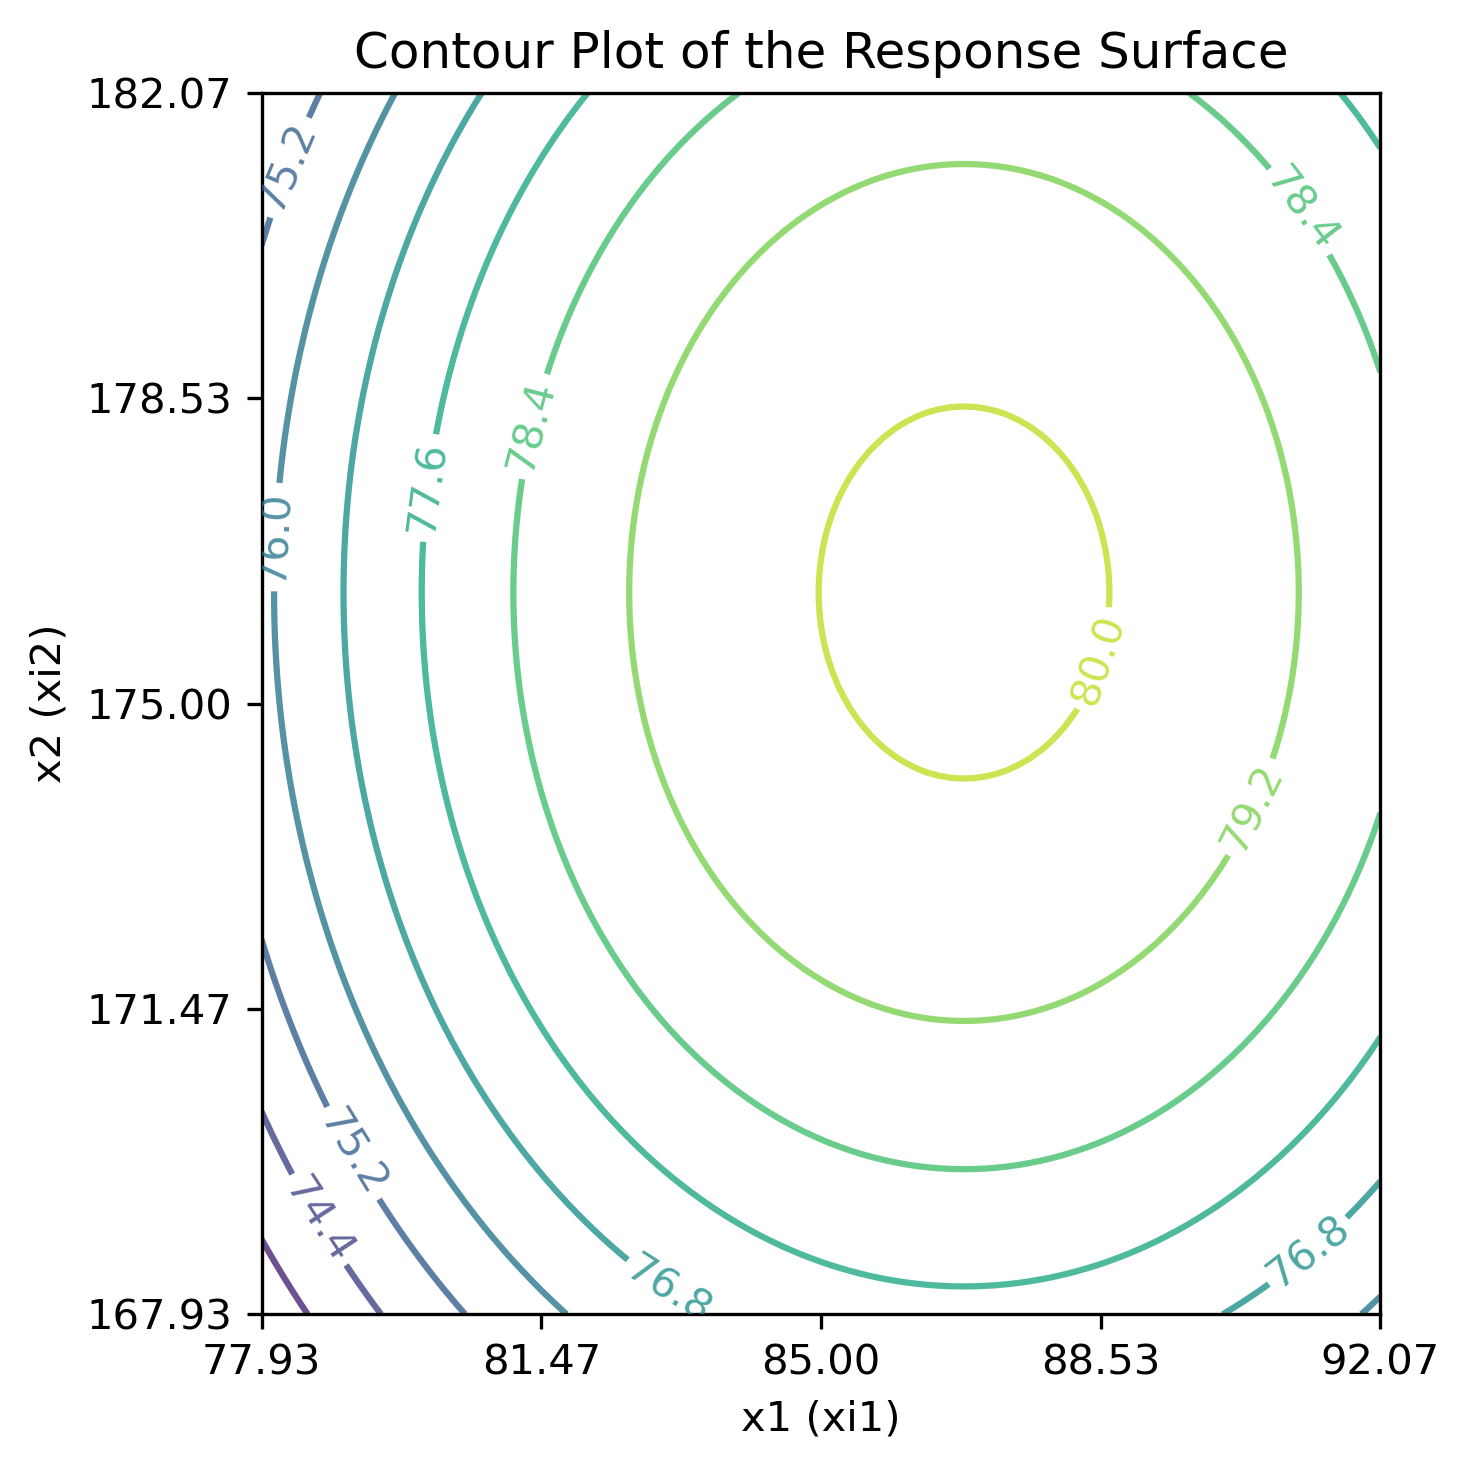

In [25]:
# Para el modelo de CO
from sklearn.preprocessing import MinMaxScaler
import itertools as it

# modelo
from copy import deepcopy
# Modificamos las variables para que pueda ser aplicado el modelo cuadratico
def cuadratic_model_variables(data_matrix, blocks = []):
    rows, columns = data_matrix.shape
    intercept = np.ones(rows)
    linear_terms = data_matrix
    squared_terms = data_matrix ** 2
    interaction_terms = []

    # Calculo de terminos de interaccion
    for i, j in combinations(range(columns), 2):
        interaction_terms.append(data_matrix[:, i] * data_matrix[:, j])

    if len(blocks) == 0:
        X = np.column_stack([intercept, linear_terms,  *interaction_terms,squared_terms,])
    else:
        X = np.column_stack([intercept, linear_terms, *interaction_terms, squared_terms, blocks])
    return X


def get_coded_funct(df, coded, real):

    coded_data = df[coded]
    real_data = df[real]
    relations = {i:j for i,j in zip(coded_data, real_data)}
    minus1 = relations[-1]
    plus1 = relations[1]
    def functr(x):
        return x * (plus1 - minus1)/2 + (plus1 + minus1)/2
    return functr

# Ignoramos el termino de bloque

# fig, ax = plt.subplots(1,3 ,figsize = (10, 5))
val_list = ['x1', 'x1']

### Forma para des-codificar los datos

codes = {
    'x1': get_coded_funct(df_respuesta, 'x1', 'xi1'),
    'x2': get_coded_funct(df_respuesta, 'x2', 'xi2'),
}

codification_names = {
    'x1': 'xi1',
    'x2': 'xi2',
}
# Generamos el modelo


model_res = ols('y ~ x1 + x2 + np.power(x1, 2) + np.power(x2,2)', data = df_respuesta).fit()

fig, ax = plt.subplots(1 ,figsize = (5, 5), dpi = 300)

# Graficamos

X, Y = np.meshgrid(np.linspace(df_respuesta['x1'].min(), df_respuesta['x1'].max(), 100),
                     np.linspace(df_respuesta['x2'].min(), df_respuesta['x2'].max(), 100))
Z = model_res.predict(exog = pd.DataFrame({'x1': X.ravel(), 'x2': Y.ravel()})).values.reshape(X.shape)

cs = ax.contour(X, Y, Z, levels=10, cmap='viridis', alpha=0.8)
ax.clabel(cs, fontsize=10)
xticks = np.linspace(df_respuesta['x1'].min(), df_respuesta['x1'].max(), 5)
ax.set_xticks(xticks)
ax.set_xticklabels([f"{codes['x1'](x):.2f}" for x in xticks])
yticks = np.linspace(df_respuesta['x2'].min(), df_respuesta['x2'].max(), 5)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{codes['x2'](y):.2f}" for y in yticks])
ax.set_xlabel('x1 (xi1)')
ax.set_ylabel('x2 (xi2)')
ax.set_title('Contour Plot of the Response Surface')
plt.tight_layout()
plt.show()


/var/folders/d4/fcz_093s76vfkprz49zjtkmc0000gn/T/ipykernel_72462/777332446.py:79: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


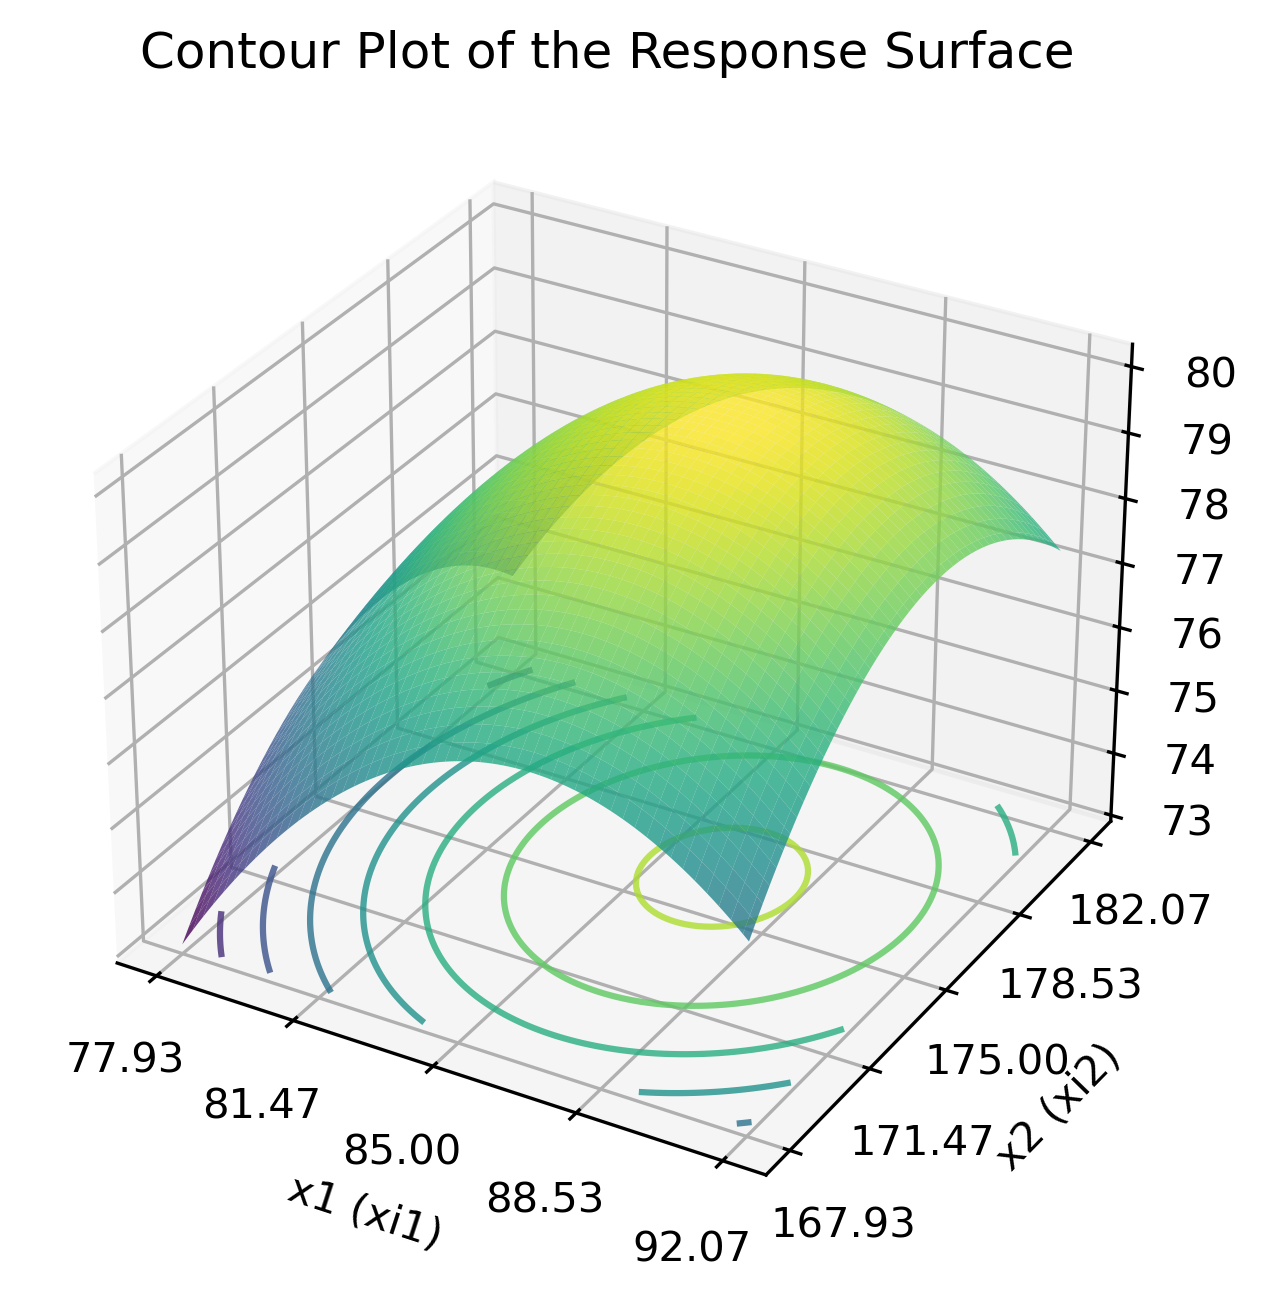

In [26]:
### Curva de respuesta
# Para el modelo de CO
from sklearn.preprocessing import MinMaxScaler
import itertools as it

# modelo
from copy import deepcopy
# Modificamos las variables para que pueda ser aplicado el modelo cuadratico
def cuadratic_model_variables(data_matrix, blocks = []):
    rows, columns = data_matrix.shape
    intercept = np.ones(rows)
    linear_terms = data_matrix
    squared_terms = data_matrix ** 2
    interaction_terms = []

    # Calculo de terminos de interaccion
    for i, j in combinations(range(columns), 2):
        interaction_terms.append(data_matrix[:, i] * data_matrix[:, j])

    if len(blocks) == 0:
        X = np.column_stack([intercept, linear_terms,  *interaction_terms,squared_terms,])
    else:
        X = np.column_stack([intercept, linear_terms, *interaction_terms, squared_terms, blocks])
    return X


def get_coded_funct(df, coded, real):

    coded_data = df[coded]
    real_data = df[real]
    relations = {i:j for i,j in zip(coded_data, real_data)}
    minus1 = relations[-1]
    plus1 = relations[1]
    def functr(x):
        return x * (plus1 - minus1)/2 + (plus1 + minus1)/2
    return functr

# Ignoramos el termino de bloque

# fig, ax = plt.subplots(1,3 ,figsize = (10, 5))
val_list = ['x1', 'x1']

### Forma para des-codificar los datos

codes = {
    'x1': get_coded_funct(df_respuesta, 'x1', 'xi1'),
    'x2': get_coded_funct(df_respuesta, 'x2', 'xi2'),
}

codification_names = {
    'x1': 'xi1',
    'x2': 'xi2',
}
# Generamos el modelo


model_res = ols('y ~ x1 + x2 + np.power(x1, 2) + np.power(x2,2)', data = df_respuesta).fit()

fig = plt.figure(figsize = (5, 5), dpi = 300)
ax = fig.add_subplot(111, projection='3d')
# Graficamos

X, Y = np.meshgrid(np.linspace(df_respuesta['x1'].min(), df_respuesta['x1'].max(), 100),
                     np.linspace(df_respuesta['x2'].min(), df_respuesta['x2'].max(), 100))
Z = model_res.predict(exog = pd.DataFrame({'x1': X.ravel(), 'x2': Y.ravel()})).values.reshape(X.shape)

cs = ax.contour(X, Y, Z, zdir = 'z', cmap='viridis', alpha=0.8, offset=np.min(Z))
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8,)

xticks = np.linspace(df_respuesta['x1'].min(), df_respuesta['x1'].max(), 5)
ax.set_xticks(xticks)
ax.set_xticklabels([f"{codes['x1'](x):.2f}" for x in xticks])
yticks = np.linspace(df_respuesta['x2'].min(), df_respuesta['x2'].max(), 5)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{codes['x2'](y):.2f}" for y in yticks])
ax.set_xlabel('x1 (xi1)')
ax.set_ylabel('x2 (xi2)')
ax.set_title('Contour Plot of the Response Surface')
plt.tight_layout()
plt.show()



## Um pouquinho da Otimizacao

Podemos ver que existe un maximo en esta curva, la cual es posible encontrar por medio de algoritmos de optimizacion.

Optimization terminated successfully.
         Current function value: -80.186058
         Iterations: 56
         Function evaluations: 108


/var/folders/d4/fcz_093s76vfkprz49zjtkmc0000gn/T/ipykernel_72462/2910016949.py:103: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


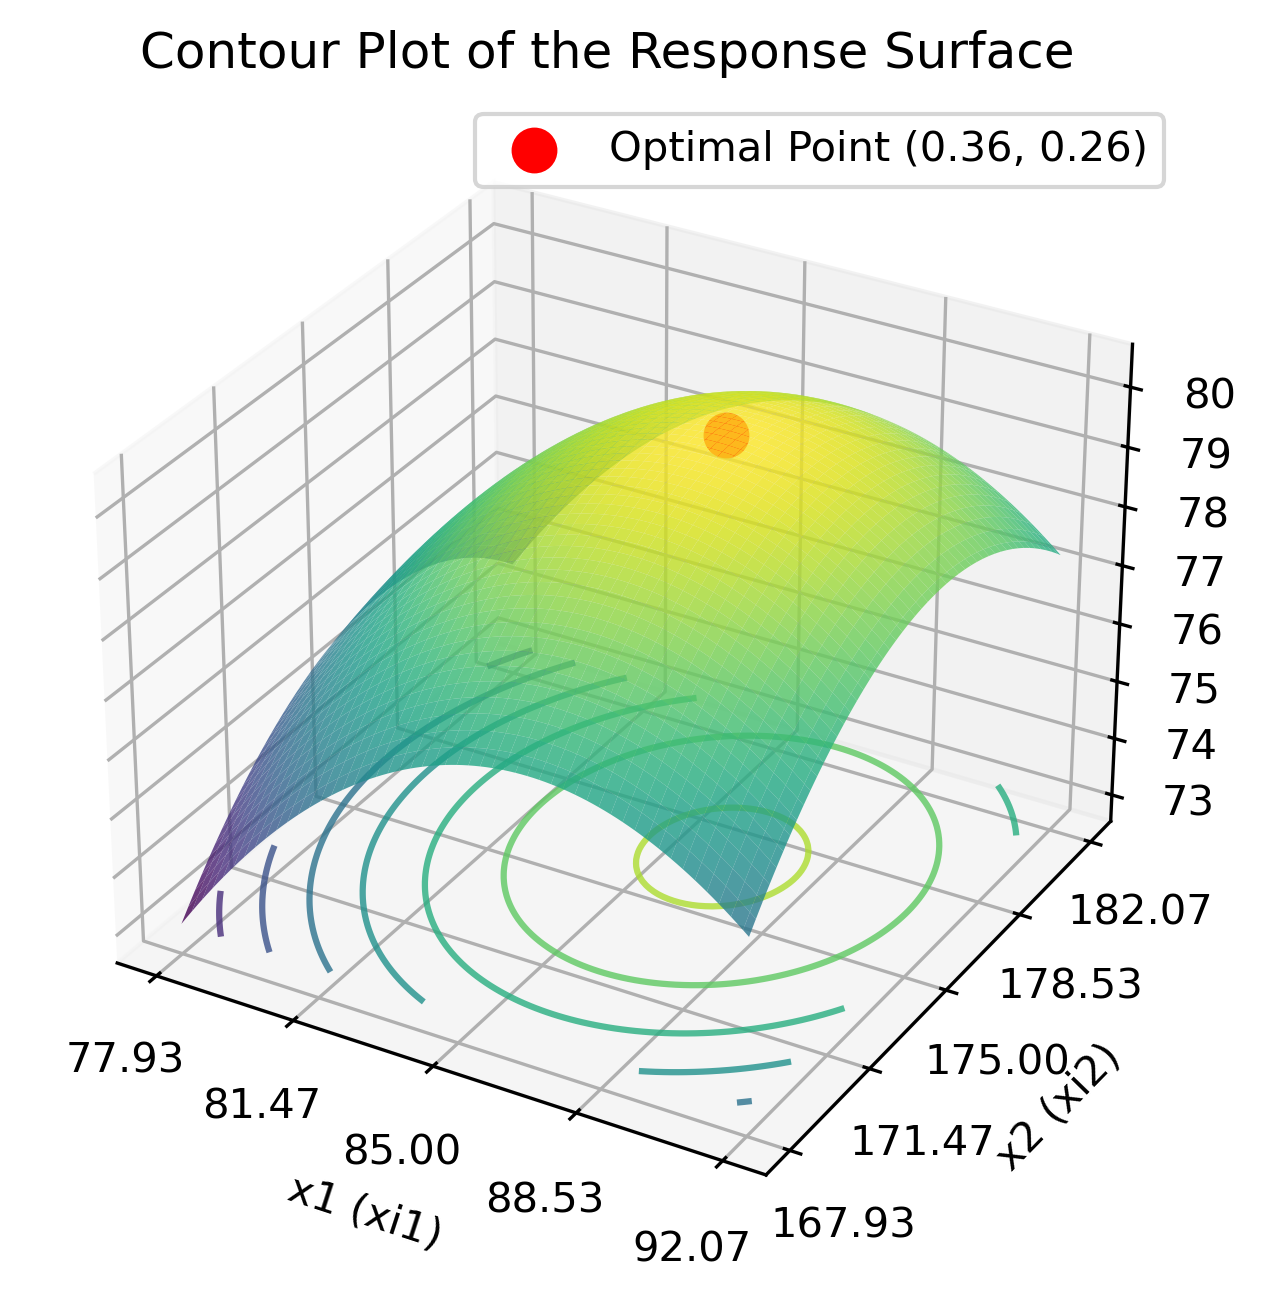

In [27]:
from scipy.optimize import minimize
def neg_response_surface_function(x, model):
    """
    Function to evaluate the response surface at given x values.
    x: array-like, shape (n_features,)
    model: fitted OLS model
    """
    x_dict = {name: val for name, val in zip(model.model.exog_names[1:], x)}
    return - model.predict(exog=pd.DataFrame([x_dict]))

def response_surface_function(x, model):
    """
    Function to evaluate the response surface at given x values.
    x: array-like, shape (n_features,)
    model: fitted OLS model
    """
    x_dict = {name: val for name, val in zip(model.model.exog_names[1:], x)}
    return model.predict(exog=pd.DataFrame([x_dict]))

res = minimize(
    fun=neg_response_surface_function,
    x0=[0, 0],  # Initial guess
    args=(model_res,),
    method='Nelder-Mead',
    options={'disp': True}
)

# graficamos el resultado en la superficie de respuesta


def cuadratic_model_variables(data_matrix, blocks = []):
    rows, columns = data_matrix.shape
    intercept = np.ones(rows)
    linear_terms = data_matrix
    squared_terms = data_matrix ** 2
    interaction_terms = []

    # Calculo de terminos de interaccion
    for i, j in combinations(range(columns), 2):
        interaction_terms.append(data_matrix[:, i] * data_matrix[:, j])

    if len(blocks) == 0:
        X = np.column_stack([intercept, linear_terms,  *interaction_terms,squared_terms,])
    else:
        X = np.column_stack([intercept, linear_terms, *interaction_terms, squared_terms, blocks])
    return X


def get_coded_funct(df, coded, real):

    coded_data = df[coded]
    real_data = df[real]
    relations = {i:j for i,j in zip(coded_data, real_data)}
    minus1 = relations[-1]
    plus1 = relations[1]
    def functr(x):
        return x * (plus1 - minus1)/2 + (plus1 + minus1)/2
    return functr

# Ignoramos el termino de bloque

# fig, ax = plt.subplots(1,3 ,figsize = (10, 5))
val_list = ['x1', 'x1']

### Forma para des-codificar los datos

codes = {
    'x1': get_coded_funct(df_respuesta, 'x1', 'xi1'),
    'x2': get_coded_funct(df_respuesta, 'x2', 'xi2'),
}

codification_names = {
    'x1': 'xi1',
    'x2': 'xi2',
}
# Generamos el modelo


model_res = ols('y ~ x1 + x2 + np.power(x1, 2) + np.power(x2,2)', data = df_respuesta).fit()

fig = plt.figure(figsize = (5, 5), dpi = 300)
ax = fig.add_subplot(111, projection='3d')
# Graficamos

X, Y = np.meshgrid(np.linspace(df_respuesta['x1'].min(), df_respuesta['x1'].max(), 100),
                     np.linspace(df_respuesta['x2'].min(), df_respuesta['x2'].max(), 100))
Z = model_res.predict(exog = pd.DataFrame({'x1': X.ravel(), 'x2': Y.ravel()})).values.reshape(X.shape)

cs = ax.contour(X, Y, Z, zdir = 'z', cmap='viridis', alpha=0.8, offset=np.min(Z))
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8,)

xticks = np.linspace(df_respuesta['x1'].min(), df_respuesta['x1'].max(), 5)
ax.set_xticks(xticks)
ax.set_xticklabels([f"{codes['x1'](x):.2f}" for x in xticks])
yticks = np.linspace(df_respuesta['x2'].min(), df_respuesta['x2'].max(), 5)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{codes['x2'](y):.2f}" for y in yticks])
ax.set_xlabel('x1 (xi1)')
ax.set_ylabel('x2 (xi2)')
ax.set_title('Contour Plot of the Response Surface')
ax.scatter(res.x[0], res.x[1], response_surface_function(res.x, model_res), color='red', s=100, label='Optimal Point (%.2f, %.2f)' % (res.x[0], res.x[1]))
ax.legend()
plt.tight_layout()
plt.show()



# Solucion Ejercicio 2 -- Diseno Box-Behnken (BBD)

**Contexto:** Se desea optimizar el porcentaje de conversion ($y$, %) en una reaccion de hidrolisis enzimatica en funcion de tres variables: temperatura ($\xi_1$, degC), tiempo de reaccion ($\xi_2$, min) y concentracion de catalizador ($\xi_3$, g/L).

Las variables codificadas se definen como:
$$x_1 = \frac{\xi_1 - 160}{20}, \quad x_2 = \frac{\xi_2 - 60}{30}, \quad x_3 = \frac{\xi_3 - 3}{2}$$

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from scipy import stats
from scipy.optimize import minimize
from itertools import combinations

df_bbd = pd.DataFrame({
    'xi1': [180, 180, 140, 140, 180, 180, 140, 140, 160, 160, 160, 160, 160, 160, 160],
    'xi2': [ 90,  30,  90,  30,  60,  60,  60,  60,  90,  90,  30,  30,  60,  60,  60],
    'xi3': [  3,   3,   3,   3,   5,   1,   5,   1,   5,   1,   5,   1,   3,   3,   3],
    'x1':  [  1,   1,  -1,  -1,   1,   1,  -1,  -1,   0,   0,   0,   0,   0,   0,   0],
    'x2':  [  1,  -1,   1,  -1,   0,   0,   0,   0,   1,   1,  -1,  -1,   0,   0,   0],
    'x3':  [  0,   0,   0,   0,   1,  -1,   1,  -1,   1,  -1,   1,  -1,   0,   0,   0],
    'y':   [74.2, 67.8, 65.2, 64.9, 74.7, 69.3, 66.8, 65.1,
            73.8, 70.3, 68.7, 67.2, 75.1, 74.9, 75.2]
})
display(df_bbd)

,xi1,xi2,xi3,x1,x2,x3,y
0,180,90,3,1,1,0,74.2
1,180,30,3,1,-1,0,67.8
2,140,90,3,-1,1,0,65.2
3,140,30,3,-1,-1,0,64.9
4,180,60,5,1,0,1,74.7
5,180,60,1,1,0,-1,69.3
6,140,60,5,-1,0,1,66.8
7,140,60,1,-1,0,-1,65.1
8,160,90,5,0,1,1,73.8
9,160,90,1,0,1,-1,70.3


## a) Comparacion estructural BBD vs CCD

> Compare el BBD con el CCD en terminos de numero de niveles por factor, numero de corridas (para $k=3$), rotabilidad y posibilidad de construccion en dos bloques. ?En que situaciones practicas preferiria un BBD sobre un CCD?

| Caracteristica | CCD | BBD |
|---|---|---|
| Niveles por factor | 5 ($-\alpha, -1, 0, 1, \alpha$) | 3 ($-1, 0, 1$) |
| Puntos axiales | Si, a distancia $\alpha = \sqrt[4]{2^k}$ | No |
| Corridas ($k=3$) | 20 ($2^3 + 6$ axiales + 6 centro) | 15 (12 aristas + 3 centro) |
| Rotabilidad | Si (con $\alpha$ apropiado) | No (pero casi rotable) |
| Construccion en 2 bloques | Si | **No** |

**Puntos clave:**
- El BBD solo usa combinaciones donde **como maximo dos factores** estan en sus niveles extremos simultaneamente; nunca se prueban los vertices del cubo ($\pm 1, \pm 1, \pm 1$). Por esto **no tiene puntos axiales** ni vertices del diseno factorial.
- El BBD es preferible cuando las condiciones extremas combinadas de todos los factores son **fisicamente impracticables o peligrosas** (ej. maxima temperatura + maxima presion + maxima concentracion simultaneamente). Tambien es preferible cuando el **presupuesto experimental es limitado** (15 vs 20 corridas para $k=3$).
- Su desventaja es que **no puede correrse secuencialmente** desde un diseno factorial previo (al contrario del CCD), por lo que el experimentador debe tener certeza de que el modelo lineal no es suficiente antes de iniciarlo.

## b) Modelo cuadratico completo y ANOVA

> Ajuste el modelo cuadratico completo (terminos lineales, cuadraticos y de interaccion) en variables codificadas. Realice el ANOVA e interprete la significancia de cada efecto.

In [29]:
formula_full = ('y ~ x1 + x2 + x3'
                '+ np.power(x1, 2) + np.power(x2, 2) + np.power(x3, 2)'
                '+ x1:x2 + x1:x3 + x2:x3')

ols_full = ols(formula_full, data=df_bbd).fit()
print(ols_full.summary())
display(anova_lm(ols_full, typ=2))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                     143.2
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           1.71e-05
Time:                        14:40:10   Log-Likelihood:              -0.050379
No. Observations:                  15   AIC:                             20.10
Df Residuals:                       5   BIC:                             27.18
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          75.0667      0.243    3

,sum_sq,df,F,PR(>F)
x1,72.000000,1.0,407.163054,0.000006
x2,27.751250,1.0,156.934496,0.000058
x3,18.301250,1.0,103.494345,0.000157
"np.power(x1, 2)",60.065641,1.0,339.673748,0.000009
"np.power(x2, 2)",33.415641,1.0,188.966867,0.000037
"np.power(x3, 2)",15.643333,1.0,88.463713,0.000229
x1:x2,9.302500,1.0,52.606032,0.000778
x1:x3,3.422500,1.0,19.354383,0.007026
x2:x3,1.000000,1.0,5.655042,0.063319
Residual,0.884167,5.0,NaN,NaN


**Interpretacion:**

El modelo ajusta muy bien los datos ($R^2 = 0.9961$). Del ANOVA tipo II con $df_{res} = 5$:

- **Todos los efectos son significativos** ($p < 0.001$) excepto la interaccion $x_2 : x_3$ ($F = 5.66$, $p \approx 0.065$), que no alcanza el nivel $\alpha = 0.05$.
- El efecto lineal de **temperatura** ($x_1$, $\hat{\beta}_1 = 3.00$) es el de mayor magnitud: a mayor temperatura, mayor conversion.
- El termino cuadratico **$x_1^2$** ($\hat{\beta}_{11} = -4.03$) es el mas pronunciado, indicando una curvatura muy marcada en la direccion de la temperatura: existe un maximo bien definido.
- La interaccion **$x_1 : x_2$** ($\hat{\beta}_{12} = 1.525$) es la mas fuerte: el efecto de la temperatura depende del tiempo de reaccion y viceversa.
- Los tres terminos cuadraticos son negativos, lo que anticipa la existencia de un **maximo** en la superficie de respuesta.

## c) Test de Lack-of-Fit y reduccion de modelo

> Realice el test de *lack-of-fit* sobre el modelo completo. Reduzca el modelo eliminando los terminos no significativos y repita el test sobre el modelo reducido.

In [30]:
def lack_of_fit_test(linear_model):
    anova_lm_test = anova_lm(linear_model, type='II')
    residual_df  = anova_lm_test.at['Residual', 'df']
    residual_ss  = anova_lm_test.at['Residual', 'sum_sq']

    unique_level = []
    count_level  = []
    exog_variables = linear_model.model.exog

    for index, point in enumerate(exog_variables):
        if list(point) not in unique_level:
            unique_level.append(list(point))
            count_level.append([1, [index], point])
        else:
            count_level[unique_level.index(list(point))][0] += 1
            count_level[unique_level.index(list(point))][1].append(index)

    SS_LOF = 0
    coefficients  = linear_model.params.values
    endog_values  = linear_model.model.endog

    for u_lev in unique_level:
        n_i, indexes, val = count_level[unique_level.index(u_lev)]
        exog_index = indexes[0] if len(indexes) > 1 else indexes[0]
        y_is      = endog_values[indexes]
        mean_y_is = np.mean(y_is)
        exog_vals = exog_variables[exog_index]
        prediction = coefficients @ exog_vals
        SS_LOF += n_i * (mean_y_is - prediction) ** 2

    SS_PE = residual_ss - SS_LOF
    m = len(unique_level)
    p = len(coefficients)
    n = len(exog_variables)

    F_val_lof = (SS_LOF / (m - p)) / (SS_PE / (n - m))
    p_val_lof = 1 - stats.f.cdf(F_val_lof, m - p, n - m)

    df_results = pd.DataFrame(np.zeros([3, 4]), columns=['df', 'sum_sq', 'F', 'p-value'])
    df_results.index = ['Residuals', 'Lack of Fit', 'Pure Error']
    df_results.at['Residuals',   'df']      = residual_df
    df_results.at['Residuals',   'sum_sq']  = residual_ss
    df_results.at['Residuals',   'F']       = np.nan
    df_results.at['Residuals',   'p-value'] = np.nan
    df_results.at['Lack of Fit', 'df']      = m - p
    df_results.at['Lack of Fit', 'sum_sq']  = SS_LOF
    df_results.at['Lack of Fit', 'F']       = F_val_lof
    df_results.at['Lack of Fit', 'p-value'] = p_val_lof
    df_results.at['Pure Error',  'df']      = n - m
    df_results.at['Pure Error',  'sum_sq']  = SS_PE
    df_results.at['Pure Error',  'F']       = np.nan
    df_results.at['Pure Error',  'p-value'] = np.nan
    return df_results


print('=== Lack-of-Fit: Modelo Completo ===')
display(lack_of_fit_test(ols_full))

=== Lack-of-Fit: Modelo Completo ===


,df,sum_sq,F,p-value
Residuals,5.0,0.884167,NaN,NaN
Lack of Fit,3.0,0.837500,11.964286,0.078117
Pure Error,2.0,0.046667,NaN,NaN


El modelo completo **no presenta lack-of-fit** ($F_{LOF} = 11.96 < F_{crit}(0.05,\,3,\,2) = 19.16$, $p > 0.05$): el modelo ajusta adecuadamente los datos.

Dado que $x_2:x_3$ no fue significativo en el ANOVA, intentamos eliminarlo y evaluamos si el modelo reducido sigue ajustando bien:

In [31]:
formula_red = ('y ~ x1 + x2 + x3'
               '+ np.power(x1, 2) + np.power(x2, 2) + np.power(x3, 2)'
               '+ x1:x2 + x1:x3')

ols_red = ols(formula_red, data=df_bbd).fit()
print(ols_red.summary())
print('\n=== Lack-of-Fit: Modelo Reducido (sin x2:x3) ===')
display(lack_of_fit_test(ols_red))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     90.32
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           1.10e-05
Time:                        14:40:10   Log-Likelihood:                -5.7248
No. Observations:                  15   AIC:                             29.45
Df Residuals:                       6   BIC:                             35.82
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          75.0667      0.324    2

,df,sum_sq,F,p-value
Residuals,6.0,1.884167,NaN,NaN
Lack of Fit,4.0,1.837500,19.6875,0.048922
Pure Error,2.0,0.046667,NaN,NaN


**Conclusion:** Al eliminar $x_2:x_3$, el modelo reducido **presenta lack-of-fit** ($F_{LOF} = 19.69 > F_{crit}(0.05,\,4,\,2) = 19.25$, $p < 0.05$), lo que indica que el termino $x_2:x_3$ --aunque marginalmente significativo-- **es necesario para mantener la bondad de ajuste**.

Por lo tanto, **se mantiene el modelo completo** para el analisis posterior.

## d) Punto optimo y superficie de respuesta

> Usando el modelo completo, estime numericamente el punto optimo y expreselo en variables naturales. Para cada par de factores, grafique los contornos y la superficie de respuesta fijando el tercer factor en su valor optimo.

In [32]:
def neg_response(x, model):
    x_dict = {'x1': x[0], 'x2': x[1], 'x3': x[2]}
    return -model.predict(exog=pd.DataFrame([x_dict])).values[0]

def response(x, model):
    x_dict = {'x1': x[0], 'x2': x[1], 'x3': x[2]}
    return model.predict(exog=pd.DataFrame([x_dict])).values[0]

res_opt = minimize(
    fun=neg_response,
    x0=[0, 0, 0],
    args=(ols_full,),
    method='Nelder-Mead',
    options={'disp': True}
)

x1_opt, x2_opt, x3_opt = res_opt.x
xi1_opt = 160 + 20 * x1_opt
xi2_opt =  60 + 30 * x2_opt
xi3_opt =   3 +  2 * x3_opt
y_opt   = response(res_opt.x, ols_full)

print(f'Punto optimo (variables codificadas):')
print(f'  x1 = {x1_opt:.4f},  x2 = {x2_opt:.4f},  x3 = {x3_opt:.4f}')
print(f'\nPunto optimo (variables naturales):')
print(f'  xi1 = {xi1_opt:.2f} degC')
print(f'  xi2 = {xi2_opt:.2f} min')
print(f'  xi3 = {xi3_opt:.2f} g/L')
print(f'\nRespuesta predicha: y_hat = {y_opt:.4f} %')

Optimization terminated successfully.
         Current function value: -76.723761
         Iterations: 111
         Function evaluations: 208
Punto optimo (variables codificadas):
  x1 = 0.5267,  x2 = 0.4884,  x3 = 0.5451

Punto optimo (variables naturales):
  xi1 = 170.53 degC
  xi2 = 74.65 min
  xi3 = 4.09 g/L

Respuesta predicha: y_hat = 76.7238 %


El punto optimo se ubica en $x_1 \approx 0.527$, $x_2 \approx 0.488$, $x_3 \approx 0.545$, equivalente a **$\xi_1 = 170.5$degC, $\xi_2 = 74.6$ min, $\xi_3 = 4.09$ g/L**, con una conversion predicha de $\hat{y} \approx 76.7\%$. El punto esta dentro de la region experimental (todos los valores codificados $< 1$).

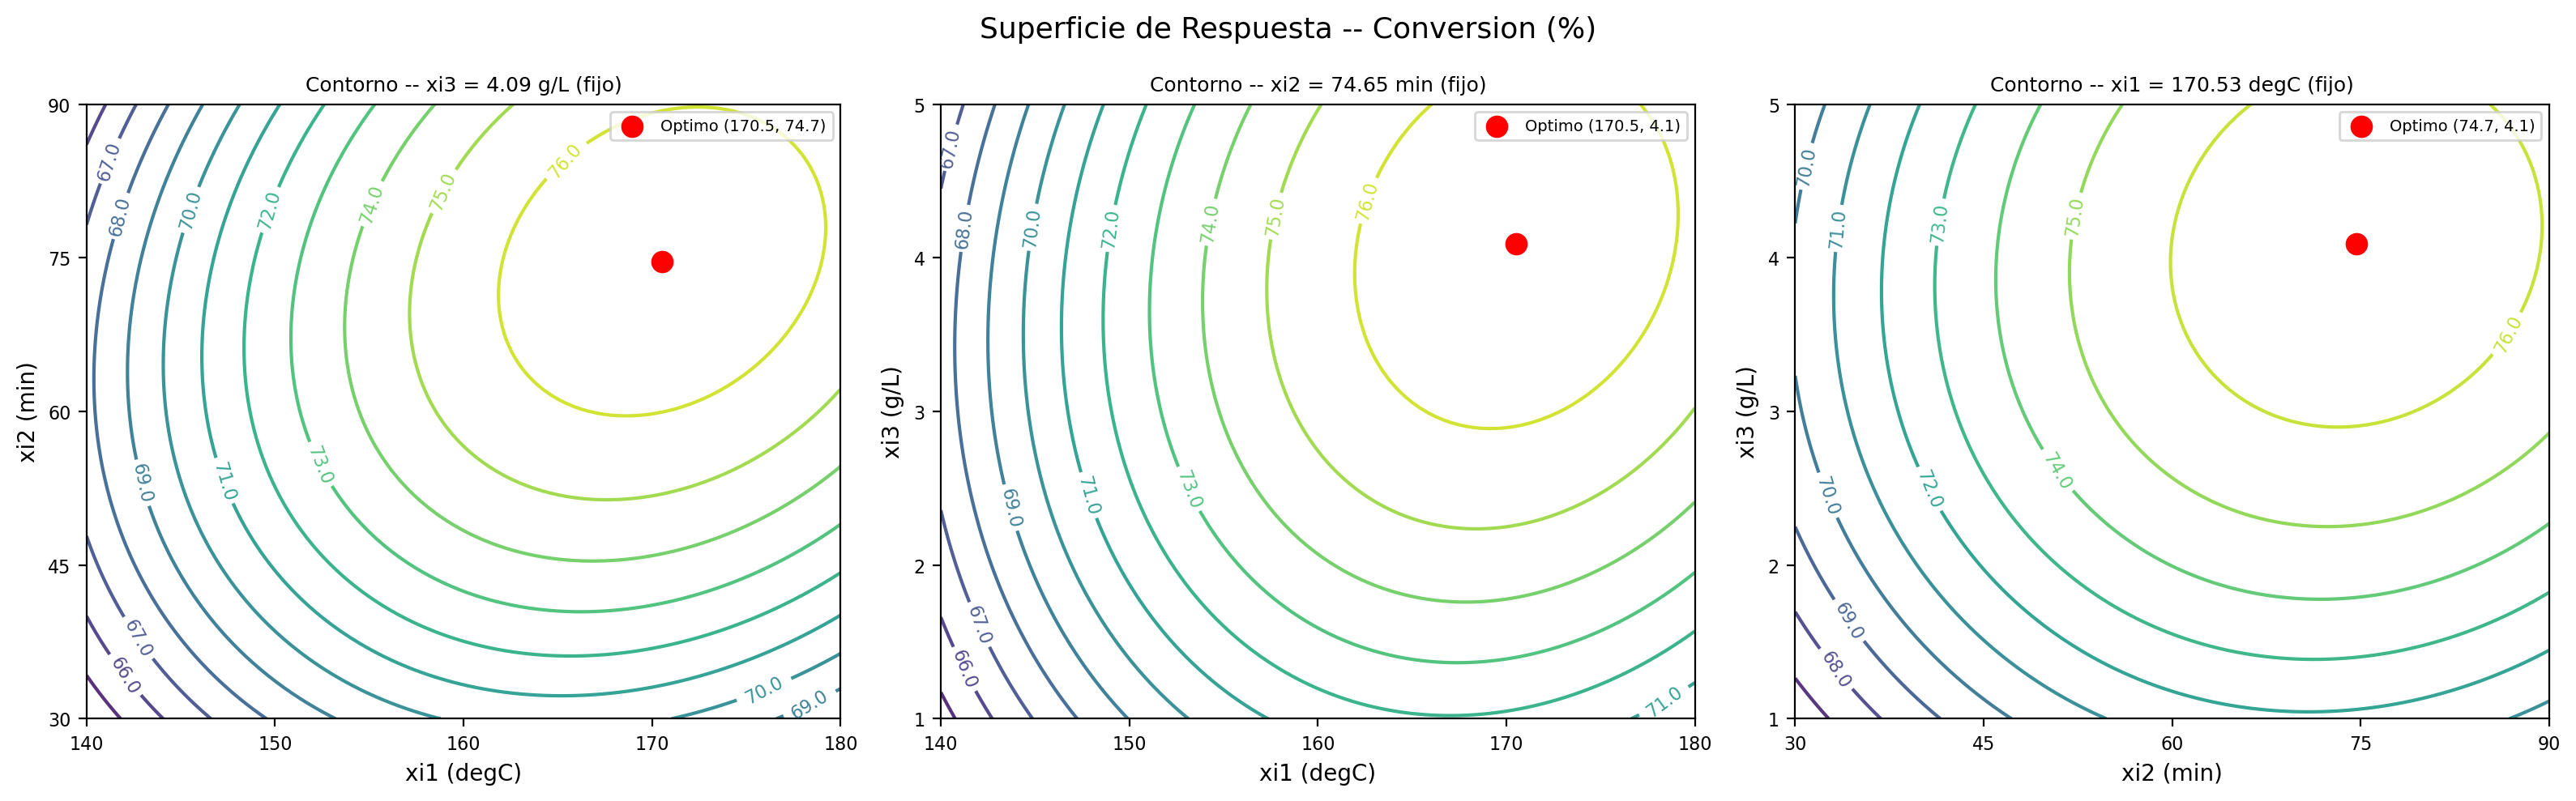

In [33]:
# Funciones de decodificacion y etiquetas
decode = {'x1': lambda z: 160 + 20*z,
          'x2': lambda z:  60 + 30*z,
          'x3': lambda z:   3 +  2*z}
labels  = {'x1': 'xi1 (degC)', 'x2': 'xi2 (min)', 'x3': 'xi3 (g/L)'}
opt_cod = {'x1': x1_opt, 'x2': x2_opt, 'x3': x3_opt}

# Tres pares: fijamos cada variable en su valor optimo
pairs = [
    ('x1', 'x2', 'x3', x3_opt, f'xi3 = {xi3_opt:.2f} g/L'),
    ('x1', 'x3', 'x2', x2_opt, f'xi2 = {xi2_opt:.2f} min'),
    ('x2', 'x3', 'x1', x1_opt, f'xi1 = {xi1_opt:.2f} degC'),
]

# -- Contour plots --
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=200)

for ax, (va, vb, vc, vc_val, vc_title) in zip(axes, pairs):
    A, B = np.meshgrid(np.linspace(-1, 1, 100), np.linspace(-1, 1, 100))
    df_pred = pd.DataFrame({
        va: A.ravel(), vb: B.ravel(), vc: np.full(A.size, vc_val)
    })
    Z = ols_full.predict(exog=df_pred).values.reshape(A.shape)

    cs = ax.contour(A, B, Z, levels=12, cmap='viridis', alpha=0.9)
    ax.clabel(cs, fontsize=8, fmt='%.1f')
    ax.scatter([opt_cod[va]], [opt_cod[vb]],
               color='red', s=80, zorder=5,
               label=f'Optimo ({decode[va](opt_cod[va]):.1f}, {decode[vb](opt_cod[vb]):.1f})')

    xticks = np.linspace(-1, 1, 5)
    ax.set_xticks(xticks)
    ax.set_xticklabels([f'{decode[va](t):.0f}' for t in xticks], fontsize=8)
    yticks = np.linspace(-1, 1, 5)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{decode[vb](t):.0f}' for t in yticks], fontsize=8)
    ax.set_xlabel(labels[va])
    ax.set_ylabel(labels[vb])
    ax.set_title(f'Contorno -- {vc_title} (fijo)', fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Superficie de Respuesta -- Conversion (%)', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretacion de los graficos:**

Los tres pares de contornos (fijando la tercera variable en su valor optimo) muestran consistentemente un **maximo bien definido** cerca del punto encontrado por el optimizador:

- **$\xi_1$-$\xi_2$ (fijando $\xi_3 = 4.09$ g/L):** Se observa que el maximo se desplaza hacia temperaturas altas (~170degC) y tiempos intermedios-altos (~75 min). La interaccion $x_1:x_2$ produce curvas de nivel elipticas inclinadas.
- **$\xi_1$-$\xi_3$ (fijando $\xi_2 = 74.6$ min):** La temperatura domina: el gradiente en $x_1$ es mas pronunciado que en $x_3$. El optimo en $\xi_3$ es moderado (~4 g/L).
- **$\xi_2$-$\xi_3$ (fijando $\xi_1 = 170.5degC$):** Las curvas son mas circulares (menor interaccion entre $x_2$ y $x_3$), confirmando que $x_2:x_3$ es el termino de menor efecto.

En los tres graficos el punto optimo (marcado en rojo) coincide con el maximo visual de la superficie, validando el resultado numerico:

$$\boxed{\xi_1^* = 170.5\,degC, \quad \xi_2^* = 74.6\,\text{min}, \quad \xi_3^* = 4.09\,\text{g/L}, \quad \hat{y}^* = 76.7\%}$$

Como practica de validacion, se recomienda realizar un **experimento confirmatorio** en estas condiciones.